CELL 1 — Install & Imports

In [1]:
!pip install kagglehub -q

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


CELL 2 — Download PlantVillage Dataset

In [2]:
import kagglehub

# Downloads to ~/.cache/kagglehub/datasets/...
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Dataset downloaded to:", path)

# Find the folder that contains class subfolders
# PlantVillage has a nested structure; find the 'color' subfolder
BASE_DIR = None
for root, dirs, files in os.walk(path):
    if len(dirs) > 10 and not files:   # class-level folder has many subdirs
        BASE_DIR = root
        break

if BASE_DIR is None:
    BASE_DIR = path   # fallback

print("Using base directory:", BASE_DIR)
classes = sorted(os.listdir(BASE_DIR))
NUM_CLASSES = len(classes)
print(f"Found {NUM_CLASSES} classes:")
for c in classes:
    print(" ", c)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded to: /kaggle/input/plantvillage-dataset
Using base directory: /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented
Found 38 classes:
  Apple___Apple_scab
  Apple___Black_rot
  Apple___Cedar_apple_rust
  Apple___healthy
  Blueberry___healthy
  Cherry_(including_sour)___Powdery_mildew
  Cherry_(including_sour)___healthy
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  Corn_(maize)___Common_rust_
  Corn_(maize)___Northern_Leaf_Blight
  Corn_(maize)___healthy
  Grape___Black_rot
  Grape___Esca_(Black_Measles)
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  Grape___healthy
  Orange___Haunglongbing_(Citrus_greening)
  Peach___Bacterial_spot
  Peach___healthy
  Pepper,_bell___Bacterial_spot
  Pepper,_bell___healthy
  Potato___Early_blight
  Potato___Late_blight
  Potato___healthy
  Raspberry___healthy
  Soybean___healthy
  Squash___Powdery_mildew
  Strawberry___Leaf_scorch
  Strawber

CELL 3 — Data Augmentation & Preprocessing

Found 38029 images belonging to 38 classes.
Found 16277 images belonging to 38 classes.

Training samples   : 38029
Validation samples : 16277


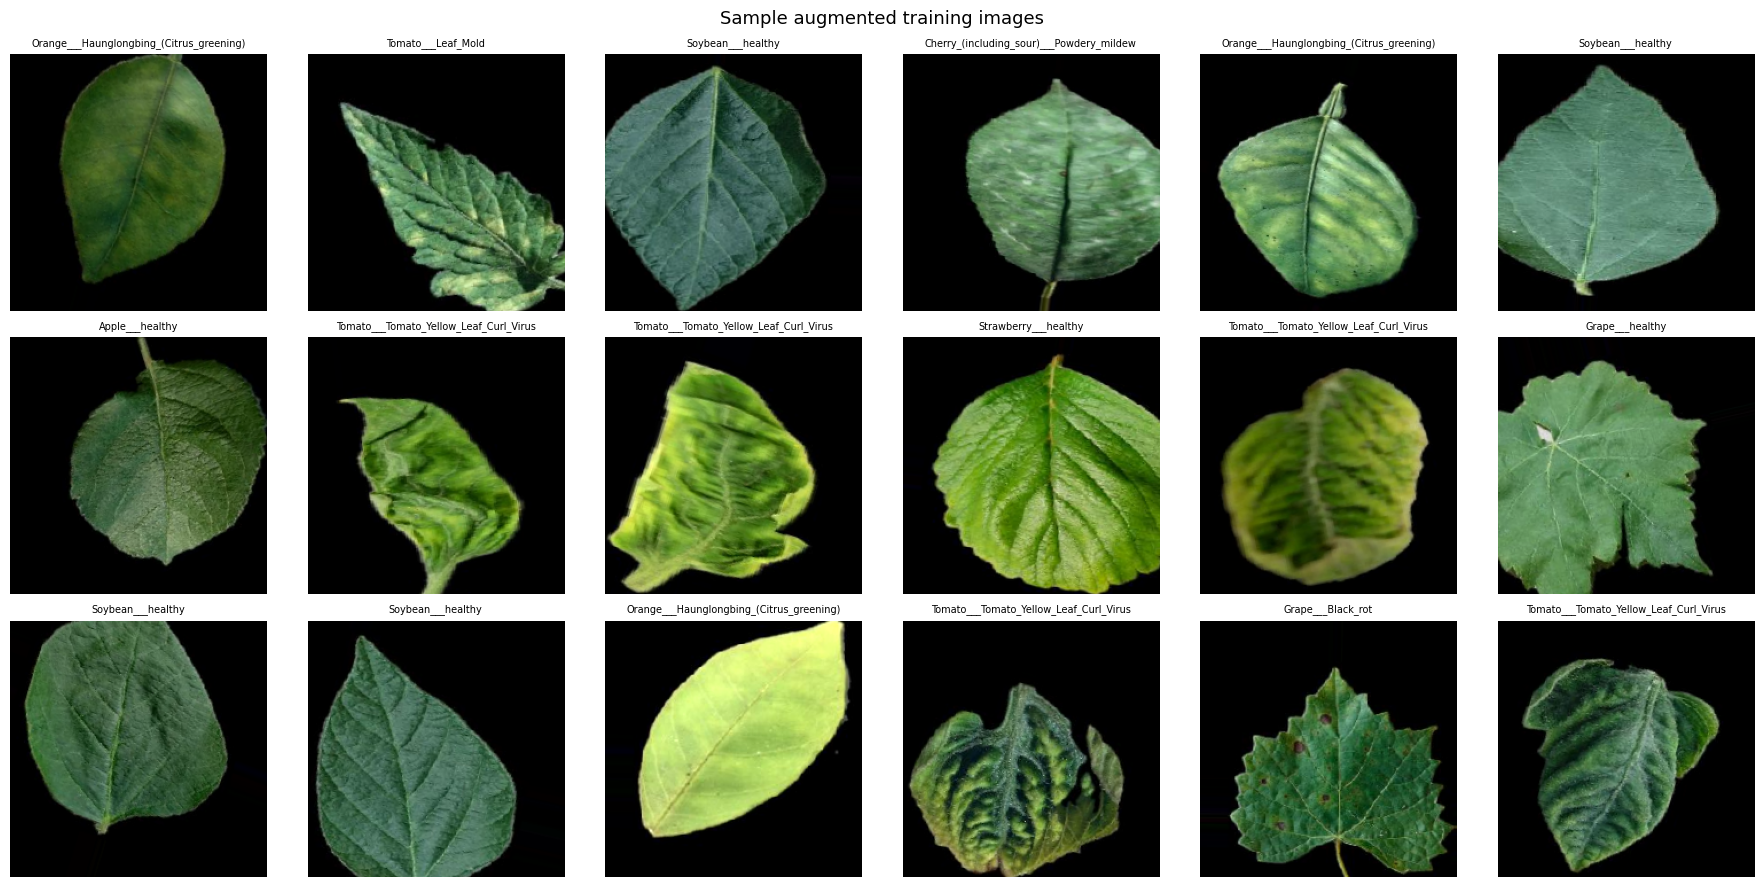

In [3]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# --- Split into train / val / test using flow_from_directory ---
# ImageDataGenerator with augmentation for training
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    validation_split   = 0.30,          # 70% train, 30% held out
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    horizontal_flip    = True,
    vertical_flip      = True,
    zoom_range         = 0.15,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest',
)

# No augmentation for val/test — only rescale
val_test_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = 0.30,
)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED,
    shuffle      = True,
)

# Use the held-out 30% and split it into val (20%) and test (10%)
# We'll do this by generating two generators with different subsets
# and taking a slice for test later
val_gen = val_test_datagen.flow_from_directory(
    BASE_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False,
)

print(f"\nTraining samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")

# Visualise a batch of augmented images
sample_images, sample_labels = next(train_gen)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.set_title(classes[np.argmax(sample_labels[i])], fontsize=7)
    ax.axis('off')
plt.suptitle("Sample augmented training images", fontsize=13)
plt.tight_layout()
plt.show()


CELL 4 — Build CNN Architecture from Scratch

In [4]:

def conv_block(x, filters, pool=True):
    """Conv → BN → ReLU  (optionally followed by MaxPool)."""
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if pool:
        x = layers.MaxPooling2D(2)(x)
    return x

def build_cnn(input_shape=(224, 224, 3), num_classes=38):
    inputs = layers.Input(shape=input_shape)

    # Block 1 — 32 filters
    x = conv_block(inputs, 32)          # → 112×112×32

    # Block 2 — 64 filters
    x = conv_block(x, 64)               # → 56×56×64

    # Block 3 — 128 filters
    x = conv_block(x, 128)              # → 28×28×128

    # Block 4 — 256 filters
    x = conv_block(x, 256)              # → 14×14×256

    # Block 5 — 512 filters (no pool — use GlobalAvgPool next)
    x = conv_block(x, 512, pool=False)  # → 14×14×512

    # Global Average Pooling replaces Flatten → fewer params, less overfit
    x = layers.GlobalAveragePooling2D()(x)  # → 512

    # Classifier head
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='PlantVillage_CNN')

model = build_cnn(num_classes=NUM_CLASSES)
model.summary()

# Count trainable parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

Model: "PlantVillage_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 4,860,038 (18.54 MB)

 Trainable params: 4,855,558 (18.52 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total parameters: 4,860,038


CELL 5 — Compile Model

In [5]:
LEARNING_RATE = 1e-3

model.compile(
    optimizer = Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

print("Model compiled successfully.")
print(f"  Optimizer : Adam  (lr={LEARNING_RATE})")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully.
  Optimizer : Adam  (lr=0.001)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


CELL 6 — Train with Callbacks

In [6]:
EPOCHS      = 20
CKPT_PATH   = 'best_plantvillage_cnn.keras'

cb_list = [
    # Stop if val_accuracy doesn't improve for 8 epochs
    callbacks.EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1,
    ),
    # Halve LR when val_loss plateaus for 4 epochs
    callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
    # Save best weights
    callbacks.ModelCheckpoint(
        filepath          = CKPT_PATH,
        monitor           = 'val_accuracy',
        save_best_only    = True,
        save_weights_only = False,
        verbose           = 1,
    ),
]

history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    callbacks       = cb_list,
    verbose         = 1,
)

print("\nTraining complete.")
print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")

Epoch 1/20
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.4031 - loss: 2.2028
Epoch 1: val_accuracy improved from None to 0.24224, saving model to best_plantvillage_cnn.keras

Epoch 1: finished saving model to best_plantvillage_cnn.keras
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 848s 689ms/step - accuracy: 0.5237 - loss: 1.6699 - val_accuracy: 0.2422 - val_loss: 3.4990 - learning_rate: 0.0010
Epoch 2/20
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7079 - loss: 0.9543
Epoch 2: val_accuracy improved from 0.24224 to 0.61117, saving model to best_plantvillage_cnn.keras

Epoch 2: finished saving model to best_plantvillage_cnn.keras
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 644s 542ms/step - accuracy: 0.7374 - loss: 0.8531 - val_accuracy: 0.6112 - val_loss: 1.3052 - learning_rate: 0.0010
Epoch 3/20
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.7976 - loss: 0.6410
Epoch 3: val_accuracy improved from 0.61117 to 0.69141, saving model to best_plantvillage_cnn.keras

Epoch 3: fin

CELL 7 — Plot Training Curves

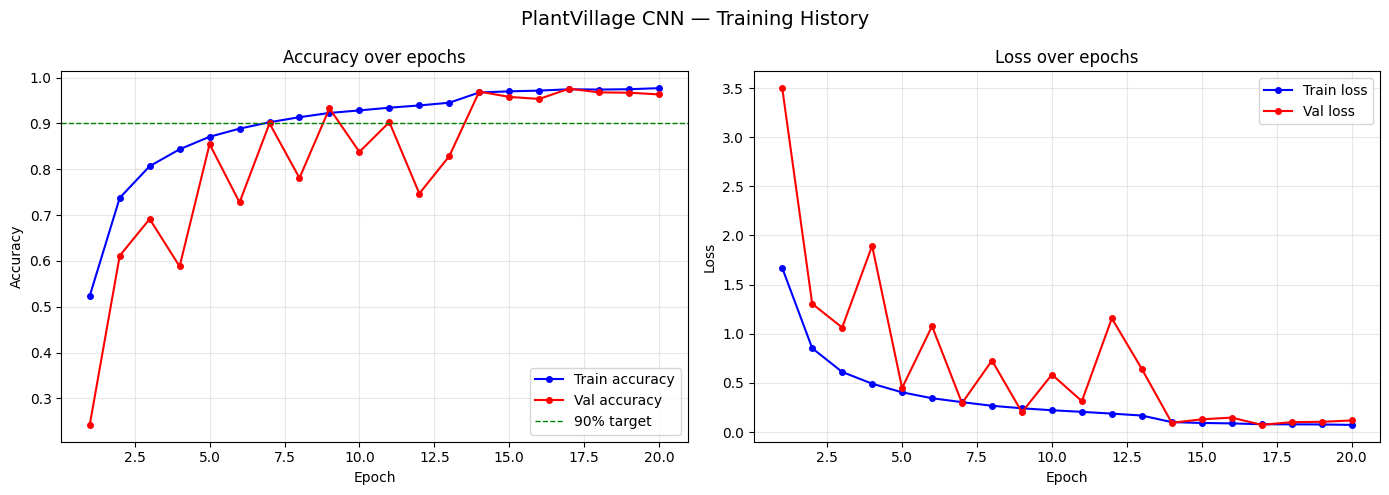

In [7]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_ran = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_ran, acc,     'b-o', markersize=4, label='Train accuracy')
ax1.plot(epochs_ran, val_acc, 'r-o', markersize=4, label='Val accuracy')
ax1.axhline(y=0.90, color='green', linestyle='--', linewidth=1, label='90% target')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_ran, loss,     'b-o', markersize=4, label='Train loss')
ax2.plot(epochs_ran, val_loss, 'r-o', markersize=4, label='Val loss')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('PlantVillage CNN — Training History', fontsize=14)
plt.tight_layout()
plt.show()

CELL 8 — Evaluate on Test Set & Classification Report

Loaded best model from: best_plantvillage_cnn.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.9757 - loss: 0.0730

Test Loss     : 0.0730
Test Accuracy : 0.9757  (97.57%)
509/509 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step

CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.949     0.995     0.972       189
                                 Apple___Black_rot      1.000     0.968     0.984       186
                          Apple___Cedar_apple_rust      1.000     0.988     0.994        82
                                   Apple___healthy      0.984     1.000     0.992       493
                               Blueberry___healthy      1.000     0.989     0.994       450
          Cherry_(including_sour)___Powdery_mildew      0.990     0.984     0.987       315
                 Cherry_(including_sour)___healthy      1.000     0.965     0.982       256
Corn_(maize

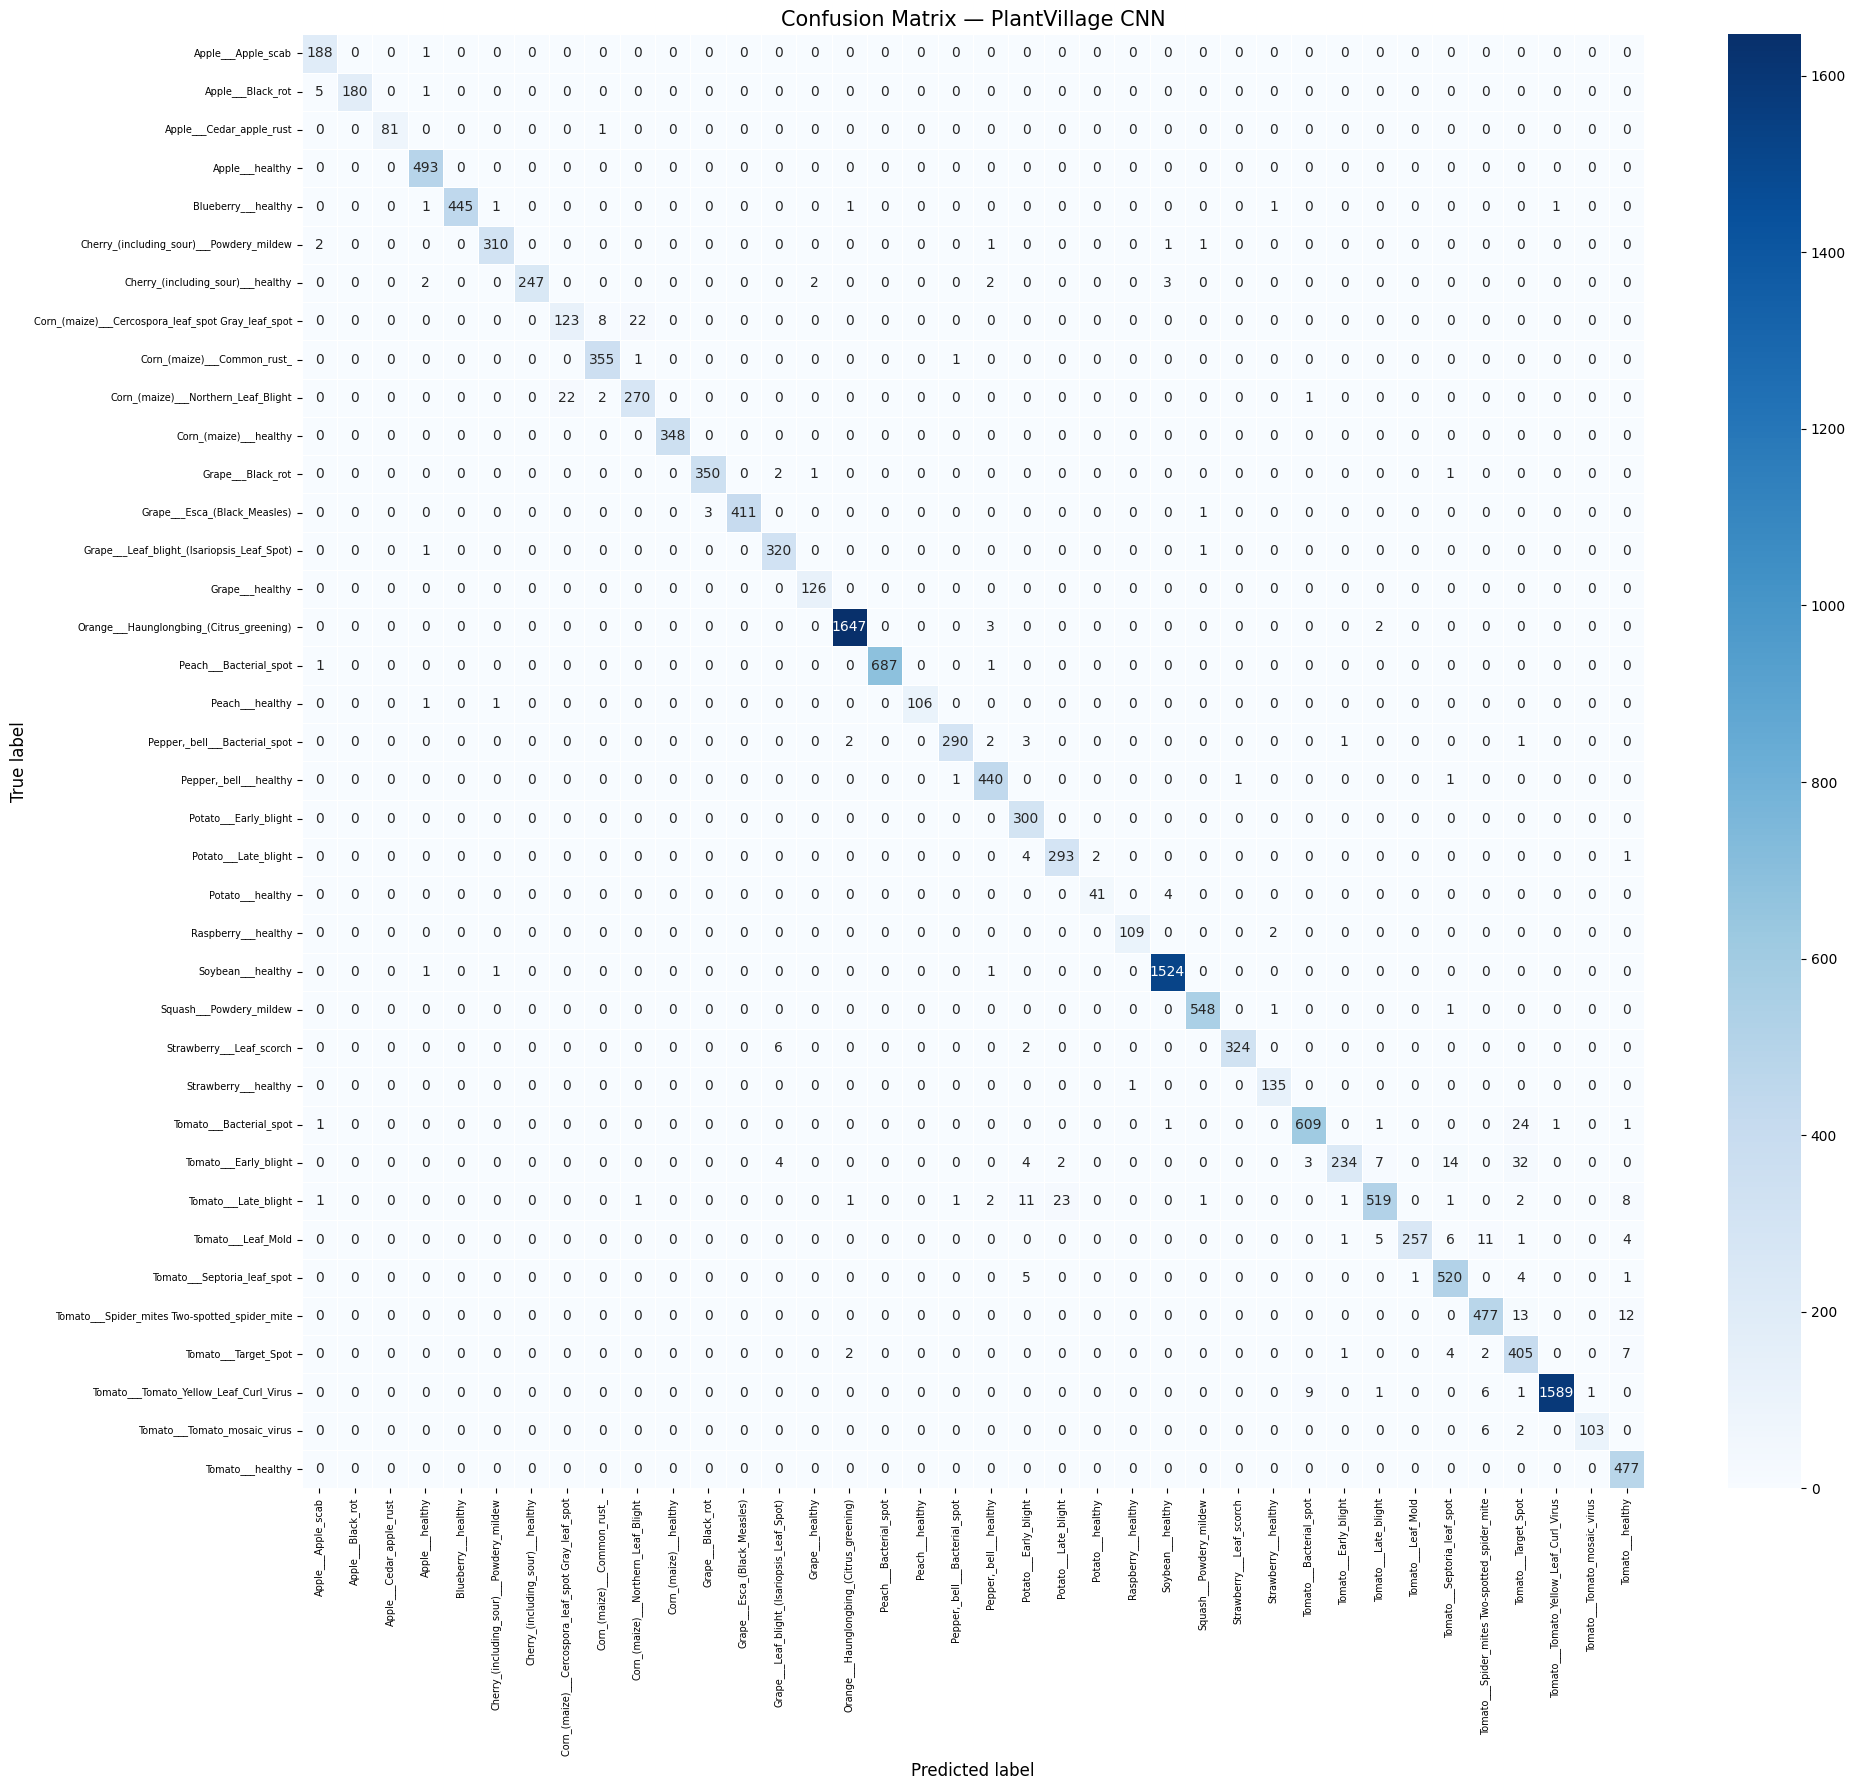


Per-class accuracy (top 5 lowest — check these first):
  Tomato___Early_blight                         78.0%
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 80.4%
  Tomato___Leaf_Mold                            90.2%
  Tomato___Late_blight                          90.7%
  Potato___healthy                              91.1%


In [8]:

# Load the best saved model
best_model = tf.keras.models.load_model(CKPT_PATH)
print(f"Loaded best model from: {CKPT_PATH}")

# Use the val_gen as the test set (shuffle=False, so labels are aligned)
# Reset generator to start from beginning
val_gen.reset()

# Evaluate
test_loss, test_acc = best_model.evaluate(val_gen, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

# Predict all test samples
val_gen.reset()
y_pred_probs = best_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# --- Classification Report ---
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_true, y_pred,
    target_names = classes,
    digits       = 3,
))

# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= classes,
    yticklabels= classes,
    linewidths = 0.5,
)
plt.title('Confusion Matrix — PlantVillage CNN', fontsize=15)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

# --- Per-class accuracy summary ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy (top 5 lowest — check these first):")
sorted_idx = np.argsort(per_class_acc)
for i in sorted_idx[:5]:
    print(f"  {classes[i]:<45} {per_class_acc[i]*100:.1f}%")